# Does SMOTE amplify data poisoning? A pilot on the Q-CHAT autism screening data

**Author:** Jeremiah Dibie · October 2026

**Research question.** When a training set is imbalanced and rebalanced with SMOTE, does a small amount of label-flipping poison do more damage than it would without SMOTE?

**Why it might.** SMOTE makes new minority-class samples by interpolating between a minority point and one of its nearest minority neighbours. If an attacker relabels a few majority-class records as minority, those poisoned points become parents of synthetic samples, and the poison spreads.

**Set-up**
- Data: Q-CHAT screening data, 1,016 toddlers, 67 high risk (6.6%). Features are sex, age, total score and the 25 items; `group` is excluded because it leaks the label.
- The **test set is split off first** (stratified 20%) and is never poisoned or resampled.
- **Poison:** relabel *k* low-risk training records as high risk, k = 0, 2, 5, 10, 15, 20, 30 (up to 3.7% of the training set). There are two attackers:
  - *random*: picks low-risk records at random (or plain label noise);
  - *outlier*: picks the low-risk records furthest from the high-risk class.
- **Rebalancing:** none · class weighting · SMOTE (k = 5 neighbours, balanced to 1:1).
- **Models:** logistic regression and RBF SVM.
- **30 repeats** with different splits, so every comparison against k = 0 is paired within a repeat.
- **Damage** is measured on the clean test set as the drop in ROC AUC and PR AUC, plus the change in false-positive rate.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from poisoning import load_qchat, run_experiment, smote_with_parents

X, y = load_qchat("../data/Qchat_Full_Polish_Cleaned.csv")
print(X.shape, "| high risk:", int(y.sum()), f"({y.mean():.1%})")

(1016, 28) | high risk: 67 (6.6%)


## 1. Sanity check: the tracked SMOTE behaves like the standard one

To count how poison spreads, I use my own SMOTE (`smote_with_parents`), which records the two parents of every synthetic sample. It follows the same sampling scheme as `imbalanced-learn`. The check below confirms that both versions give the same cross-validated performance.

In [2]:
from sklearn.base import BaseEstimator

class TrackedSMOTE(BaseEstimator):
    # Minimal sampler wrapper so the tracked SMOTE can run inside an imblearn Pipeline
    def __init__(self, k_neighbors=5, random_state=None):
        self.k_neighbors, self.random_state = k_neighbors, random_state
    def fit_resample(self, X, y):
        y = np.asarray(y)
        Xm = X[y == 1]
        n_new = int((y == 0).sum() - (y == 1).sum())
        Xn, _, _ = smote_with_parents(Xm, n_new, self.k_neighbors, self.random_state)
        return np.vstack([X, Xn]), np.concatenate([y, np.ones(n_new, int)])

cv = StratifiedKFold(5, shuffle=True, random_state=0)
for name, sampler in [("imbalanced-learn SMOTE", SMOTE(random_state=0)), ("tracked SMOTE", TrackedSMOTE(random_state=0))]:
    pipe = Pipeline([("scale", StandardScaler()), ("smote", sampler), ("lr", LogisticRegression(max_iter=5000))])
    s = cross_val_score(pipe, X.to_numpy(float), y.to_numpy(), cv=cv, scoring="roc_auc")
    print(f"{name:24s} ROC AUC {s.mean():.3f} ± {s.std():.3f}")

imbalanced-learn SMOTE   ROC AUC 0.729 ± 0.037


tracked SMOTE            ROC AUC 0.732 ± 0.042


## 2. Run the experiment

2 attacks × 7 poison levels × 3 rebalancing methods × 2 models × 30 repeats = 2,520 fitted models. This takes about 1–2 minutes.

In [3]:
res = run_experiment(X, y, n_repeats=30)
res.to_csv("../results/results.csv", index=False)

# Paired damage: each run compared with the unpoisoned run of the same repeat, attack, model and method
keys = ["repeat", "attack", "model", "method"]
base = res[res.poisoned == 0].set_index(keys)[["roc_auc", "pr_auc", "fpr"]]
res = res.join(base, on=keys, rsuffix="_clean")
for m in ["roc_auc", "pr_auc", "fpr"]:
    res[f"d_{m}"] = res[m] - res[f"{m}_clean"]
print(len(res), "runs")

2520 runs


In [4]:
# Shared chart style
COLORS = {"smote": "#2a78d6", "class_weight": "#eb6834", "none": "#1baf7a"}
LABELS = {"smote": "SMOTE", "class_weight": "Class weighting", "none": "No rebalancing"}
MARKERS = {"smote": "o", "class_weight": "s", "none": "^"}
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.edgecolor": "#c9c8c3", "axes.labelcolor": MUTED,
                     "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlecolor": INK,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8,
                     "font.size": 10, "axes.titlesize": 11})

def ci(s):
    return 1.96 * s.std() / np.sqrt(len(s))

## 3. Does SMOTE spread the poison?

For each poison level, the chart compares two quantities: the share of the minority class that is poisoned *before* SMOTE, and the share of the rebalanced minority class (real plus synthetic) that is poisoned or was built from a poisoned parent *after* SMOTE. If SMOTE did not spread poison, the points would sit on the dashed line.

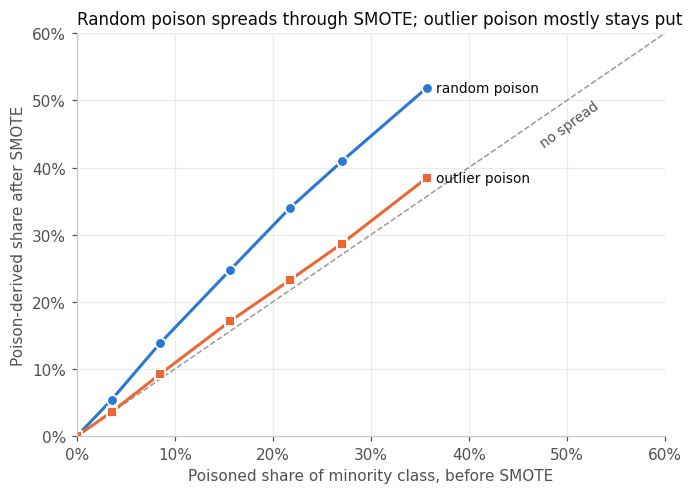

poison_share_before  poison_share_after  \
attack  poisoned                                            
outlier 0                       0.000               0.000   
        2                       0.036               0.036   
        5                       0.085               0.092   
        10                      0.156               0.171   
        15                      0.217               0.232   
        20                      0.270               0.287   
        30                      0.357               0.385   
random  0                       0.000               0.000   
        2                       0.036               0.055   
        5                       0.085               0.138   
        10                      0.156               0.247   
        15                      0.217               0.340   
        20                      0.270               0.409   
        30                      0.357               0.519   

                  synthetic_from_poison_any  per_poisoned_point  
attack  poisoned                                                 
outlier 0                             0.000                 NaN  
        2                            25.433              12.717  
        5                            64.433              12.887  
        10                          117.967              11.797  
        15                          157.700              10.513  
        20                          191.500               9.575  
        30                          250.033               8.334  
random  0                             0.000                 NaN  
        2                            39.233              19.617  
        5                            99.000              19.800  
        10                          174.933              17.493  
        15                          237.433              15.829  
        20                          282.000              14.100  
        30                          347.667              11.589

In [5]:
sm = res[(res.method == "smote") & (res.model == "Logistic Regression")]
spread = sm.groupby(["attack", "poisoned"])[["poison_share_before", "poison_share_after",
                                              "synthetic_from_poison_any"]].mean()

fig, ax = plt.subplots(figsize=(6.4, 4.6))
lim = 0.6
ax.plot([0, lim], [0, lim], ls="--", lw=1, color="#9b9a95")
ax.text(0.47, 0.43, "no spread", color=MUTED, fontsize=9, rotation=36)
for attack, col, mk in [("random", "#2a78d6", "o"), ("outlier", "#eb6834", "s")]:
    d = spread.loc[attack]
    ax.plot(d.poison_share_before, d.poison_share_after, color=col, lw=2, marker=mk, ms=7,
            markeredgecolor="white", markeredgewidth=1.2)
    x, yv = d.poison_share_before.iloc[-1], d.poison_share_after.iloc[-1]
    ax.annotate(f"{attack} poison", (x, yv), xytext=(6, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Poisoned share of minority class, before SMOTE")
ax.set_ylabel("Poison-derived share after SMOTE")
ax.set_title("Random poison spreads through SMOTE; outlier poison mostly stays put", loc="left")
plt.tight_layout()
plt.savefig("../images/poison_spread.png", dpi=150)
plt.show()

table = spread.assign(per_poisoned_point=lambda d: d.synthetic_from_poison_any / d.index.get_level_values("poisoned"))
table.round(3)

## 4. Does the spread translate into damage?

The chart shows the drop in ROC AUC on the clean test set relative to the same model trained without poison. Bands are 95% confidence intervals over 30 paired repeats.

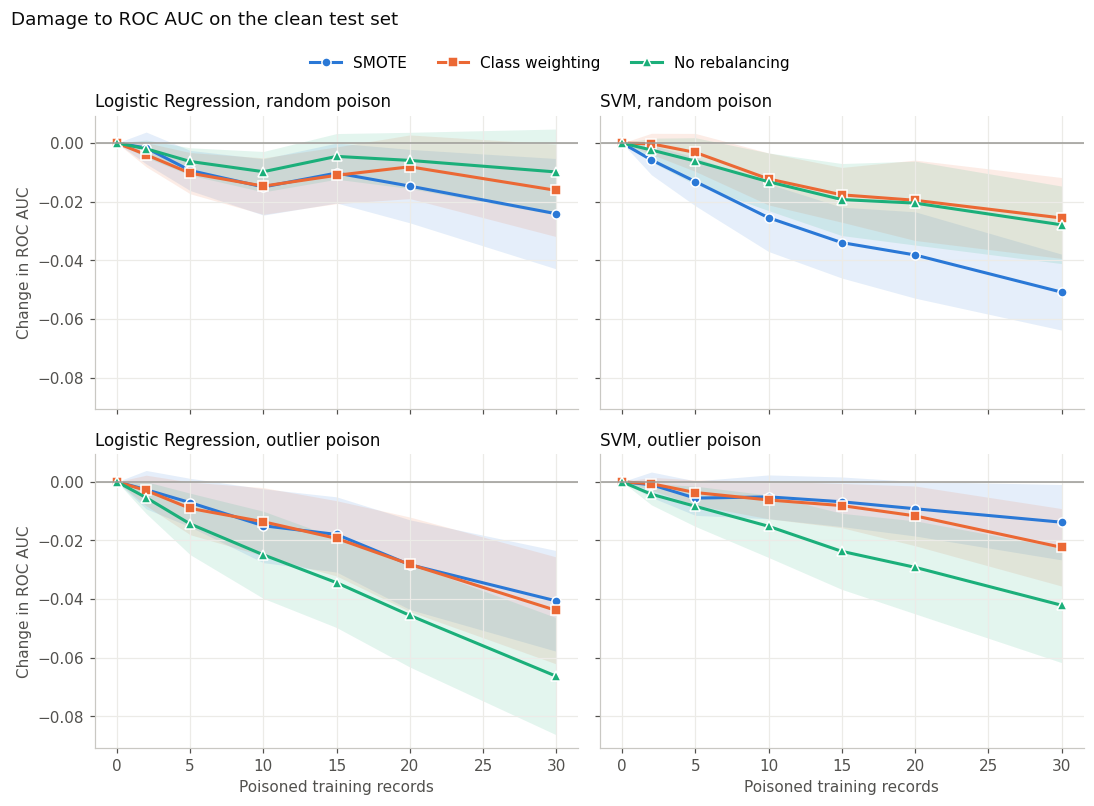

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for i, attack in enumerate(["random", "outlier"]):
    for j, model in enumerate(["Logistic Regression", "SVM"]):
        ax = axes[i, j]
        sub = res[(res.attack == attack) & (res.model == model)]
        for method in ["smote", "class_weight", "none"]:
            g = sub[sub.method == method].groupby("poisoned")["d_roc_auc"]
            m, e = g.mean(), g.apply(ci)
            ax.fill_between(m.index, m - e, m + e, color=COLORS[method], alpha=0.12, lw=0)
            ax.plot(m.index, m, color=COLORS[method], lw=2, marker=MARKERS[method], ms=6,
                    markeredgecolor="white", markeredgewidth=1, label=LABELS[method])
        ax.axhline(0, color="#9b9a95", lw=1)
        ax.set_title(f"{model}, {attack} poison", loc="left")
        if i == 1: ax.set_xlabel("Poisoned training records")
        if j == 0: ax.set_ylabel("Change in ROC AUC")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Damage to ROC AUC on the clean test set", x=0.01, ha="left", y=1.04, color=INK, fontsize=12)
plt.tight_layout()
plt.savefig("../images/damage_roc_auc.png", dpi=150, bbox_inches="tight")
plt.show()

### Damage at the highest poison level (30 records, 3.7% of training data)

In [7]:
k30 = res[res.poisoned == 30]
summary = (k30.groupby(["attack", "model", "method"])
              .agg(roc_auc_change=("d_roc_auc", "mean"), roc_ci=("d_roc_auc", ci),
                   pr_auc_change=("d_pr_auc", "mean"), pr_ci=("d_pr_auc", ci),
                   fpr_change=("d_fpr", "mean")))
summary.round(3)

roc_auc_change  roc_ci  \
attack  model               method                                 
outlier Logistic Regression class_weight          -0.044   0.018   
                            none                  -0.066   0.020   
                            smote                 -0.041   0.017   
        SVM                 class_weight          -0.022   0.013   
                            none                  -0.042   0.020   
                            smote                 -0.014   0.013   
random  Logistic Regression class_weight          -0.016   0.016   
                            none                  -0.010   0.015   
                            smote                 -0.024   0.019   
        SVM                 class_weight          -0.026   0.014   
                            none                  -0.028   0.013   
                            smote                 -0.051   0.013   

                                          pr_auc_change  pr_ci  fpr_change  
attack  model               method                                          
outlier Logistic Regression class_weight         -0.064  0.021       0.002  
                            none                 -0.080  0.028       0.029  
                            smote                -0.068  0.025       0.017  
        SVM                 class_weight         -0.059  0.022       0.044  
                            none                 -0.126  0.031       0.017  
                            smote                -0.043  0.019       0.050  
random  Logistic Regression class_weight         -0.017  0.027       0.072  
                            none                 -0.012  0.020      -0.003  
                            smote                -0.014  0.029       0.077  
        SVM                 class_weight         -0.028  0.019       0.069  
                            none                 -0.031  0.016       0.000  
                            smote                -0.036  0.016       0.047

In [8]:
# Paired test: is SMOTE's damage different from class weighting's in the same repeat?
w = k30.pivot_table(index=["repeat", "attack", "model"], columns="method", values="d_roc_auc")
diff = (w["smote"] - w["class_weight"]).groupby(level=["attack", "model"])
pd.DataFrame({"SMOTE minus class weighting (ROC AUC change)": diff.mean(), "95% CI ±": diff.apply(ci)}).round(3)

SMOTE minus class weighting (ROC AUC change)  \
attack  model                                                               
outlier Logistic Regression                                         0.003   
        SVM                                                         0.009   
random  Logistic Regression                                        -0.008   
        SVM                                                        -0.025   

                             95% CI ±  
attack  model                          
outlier Logistic Regression     0.006  
        SVM                     0.007  
random  Logistic Regression     0.007  
        SVM                     0.010

## 5. Findings

1. **SMOTE does spread poison, and how much depends on where the poison sits.** With random label flips, 30 poisoned records (36% of the real minority class) became **52%** of the rebalanced minority class. Each poisoned record seeded about **12 synthetic samples**. Outlier poison spreads much less (36% → 39%). Records far from the real high-risk children mainly interpolate with each other, so they stay in their own region.
2. **For random poison, the spread turns into extra damage, clearly so for the SVM.** At 30 poisoned records, the SVM trained with SMOTE lost about **0.05 ROC AUC**, around twice the loss under class weighting or no rebalancing. The paired difference against class weighting is significant (see the table above). For logistic regression the gap is smaller and borderline.
3. **For outlier poison, SMOTE is not the weak point.** The model *without* rebalancing suffers most here, and SMOTE does no worse than class weighting.
4. **Rebalancing raises false alarms under poisoning.** With class weighting or SMOTE, random poison increases the false-positive rate by up to about 8 percentage points. In a screening setting, that means more families sent for unnecessary follow-up.

**Takeaway:** oversampling interacts with poisoning in a measurable way, but the effect depends on the model and on where the poison lands. Poison that blends into the minority class is amplified; poison far from it is not. This supports studying the interaction systematically (RQ1 of my PhD proposal) rather than assuming SMOTE is always worse.

## 6. Limitations and next steps

- This is a pilot on one small dataset with weak signal (ROC AUC ≈ 0.77) and only about 13 high-risk children per test set, so effects are noisy even with 30 repeats.
- It covers one attack type (label flipping) and two models.
- **Next:** derive the expected poison-derived share mathematically and compare it with the measured curve. Repeat on a larger, higher-signal security dataset (e.g. CIC-IDS2017). Test smarter attacks that place poison near the minority class on purpose. Check whether shifts in SHAP attributions can detect the poisoned batches.